Begin with an image:

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

For implementation we begin with classical gradient flow on $R$. 
We have 
$$
        \text{I}(\rho) = \rho_\text{I}(x,z) = \int_0^1\rho(x,y,z)dy \\
        \text{II}(\rho) = \rho_\text{II}(y,z) = \int_0^1 \rho(x,y,z)dx
$$

$$
        \mathcal{E} = \frac{1}{2}||\text{I}(R)-\rho_\text{I}||_2^2 + \frac{1}{2}||\text{II}(R)-\rho_\text{II}||_2^2 + \text{regularisation}
$$

$$
        R = \arg \min \mathcal{E}
$$

Suppose $R = R[i,j,k]$ is a 3D array.

In [2]:
# image parameters
g = 1
t = 5

# image paths
xz_path = (f"../../data/synthetic/images/gen_{g:02d}/plant_gen{g:02d}_t{t:02d}_xz.png")

yz_path = (f"../../data/synthetic/images/gen_{g:02d}/plant_gen{g:02d}_t{t:02d}_yz.png")

# load images
img_xz = cv2.imread(xz_path, cv2.IMREAD_GRAYSCALE)
img_yz = cv2.imread(yz_path, cv2.IMREAD_GRAYSCALE)

if img_xz is None:
    raise FileNotFoundError(xz_path)

if img_yz is None:
    raise FileNotFoundError(yz_path)

# convert to [0,1]
# rho_xz and rho_yz are the probability distributions along the xz and yz planes
# (x,z) and (y,z) respectively. The .T is to transpose the arrays so that the z-axis is the first axis.
rho_xz = (img_xz > 0).astype(np.float32).T
rho_yz = (img_yz > 0).astype(np.float32).T

# optional denoising / uncertainty model
# rho_xz = cv2.GaussianBlur(rho_xz, (0, 0), sigmaX=2)
# rho_yz = cv2.GaussianBlur(rho_yz, (0, 0), sigmaX=2)

# construct R0
R0 = rho_xz[:, None, :] * rho_yz[None, :, :]

print("rho_xz shape:", rho_xz.shape)
print("rho_yz shape:", rho_yz.shape)
print("R0 shape:", R0.shape)
print("R0 mass:", R0.sum())

rho_xz shape: (512, 512)
rho_yz shape: (512, 512)
R0 shape: (512, 512, 512)
R0 mass: 2083.0


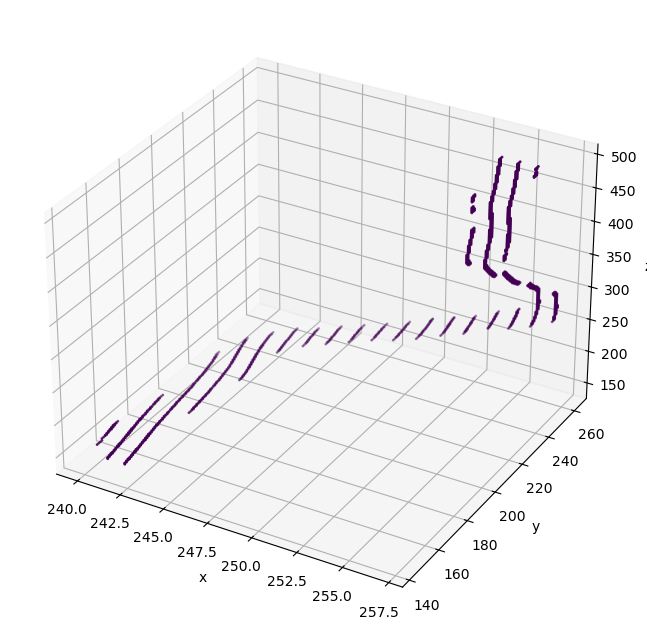

In [3]:
threshold = 0

x, y, z = np.where(R0 > threshold)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x, y, z, s=1, c=R0[x,y,z], cmap='viridis')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

plt.show()

In [4]:
I_R = np.sum(R0, axis = 1)  # sum over y-axis
II_R = np.sum(R0, axis = 0)  # sum over x-axis

print("I_R shape:", I_R.shape)
print("II_R shape:", II_R.shape)

I_R shape: (512, 512)
II_R shape: (512, 512)


In [ ]:
# define error 
e_xz = I_R - rho_xz
e_yz = II_R - rho_yz

In [5]:
curve = []

Nx, Ny, Nz = R0.shape
X, Y = np.meshgrid(np.arange(Nx), np.arange(Ny), indexing='ij')

for z in range(Nz):
    P = R0[:, :, z]

    mass = np.sum(P)

    if mass < 1e-12:
        continue

    x = float(np.sum(X * P) / mass)
    y = float(np.sum(Y * P) / mass)

    curve.append([x, y, z])

curve = np.array(curve)

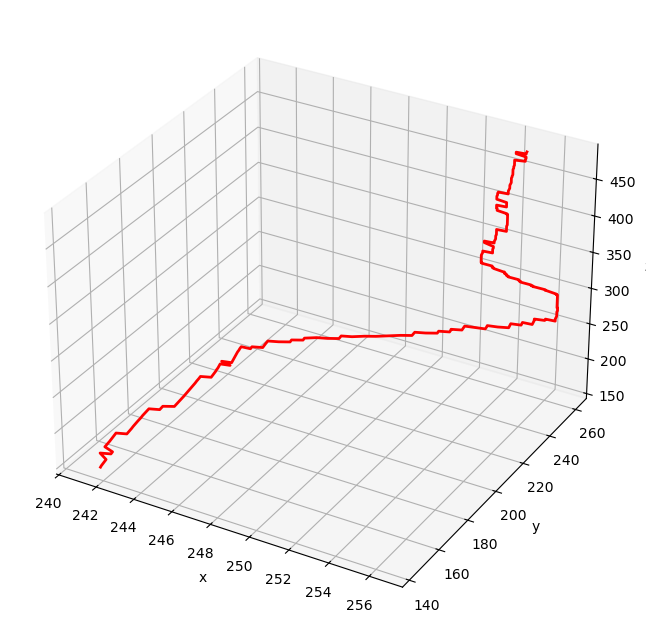

In [11]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(
    curve[:,0],
    curve[:,1],
    curve[:,2],
    'r-',
    linewidth=2
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()